# Machine Learning–Based Prediction of Tsunami Occurrence from Seismic Event Data

## Capstone Project – B.Tech (8th Semester)

### Objective
To develop a supervised machine learning framework that predicts the likelihood of tsunami occurrence following an earthquake using real-world seismic event data.

### Tools & Technologies
- Python
- Jupyter Notebook
- Pandas, NumPy
- Scikit-learn
- XGBoost
- Matplotlib, Seaborn

### Data Sources
- Global Earthquake Catalogs
- Global Historical Tsunami Databases


In [2]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


## 1. Data Loading and Initial Inspection

In this section, real-world earthquake and tsunami datasets are loaded and examined to understand their structure, attributes, and overall quality before preprocessing.


In [5]:
# Define data directory path
DATA_PATH = "data/"

In [7]:
# Load the USGS earthquake dataset
# earthquake_df = pd.read_csv(DATA_PATH + "earthquakes_usgs.csv")

# Check dataset shape (rows, columns)
# earthquake_df.shape


In [9]:
# Load and merge USGS earthquake datasets (split due to API row limits)

files = [
    "eq_2000_2005.csv",
    "eq_2006_2010.csv",
    "eq_2011_2015.csv",
    "eq_2016_2020.csv",
    "eq_2021_2026.csv"
]

dfs = [pd.read_csv(DATA_PATH + f) for f in files]
earthquake_df = pd.concat(dfs, ignore_index=True)

# Convert time to datetime and remove timezone
earthquake_df['time'] = pd.to_datetime(earthquake_df['time']).dt.tz_convert(None)

# Initialize tsunami label
earthquake_df['tsunami'] = 0

# Check merged dataset shape
earthquake_df.shape

(46663, 23)

In [11]:
# Display first 5 rows
earthquake_df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,tsunami
0,2005-12-31 12:14:02.240,-28.988,-71.519,25.0,5.0,mwc,42.0,84.3,NaN,1.00,...,"87 km WSW of Vallenar, Chile",earthquake,NaN,14.8,NaN,NaN,reviewed,us,hrv,0
1,2005-12-31 09:29:27.350,-27.180,-176.434,35.0,5.2,mwc,89.0,75.4,NaN,0.85,...,Kermadec Islands region,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,0
2,2005-12-30 18:26:43.900,7.529,-82.266,10.0,6.1,mwb,420.0,50.1,NaN,0.96,...,"76 km S of Boca Chica, Panama",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us,0
3,2005-12-29 08:30:34.480,27.367,139.853,472.3,5.3,mwc,267.0,34.2,NaN,0.85,...,"Bonin Islands, Japan region",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,0
4,2005-12-29 07:20:55.730,25.010,96.197,12.0,5.1,mwc,132.0,49.8,NaN,0.82,...,"127 km WSW of Myitkyina, Myanmar",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv,0


In [13]:
# Display column names
earthquake_df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource', 'tsunami'],
      dtype='object')

In [15]:
# Basic dataset information
earthquake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46663 entries, 0 to 46662
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   time             46663 non-null  datetime64[ns]
 1   latitude         46663 non-null  float64       
 2   longitude        46663 non-null  float64       
 3   depth            46663 non-null  float64       
 4   mag              46663 non-null  float64       
 5   magType          46663 non-null  object        
 6   nst              31048 non-null  float64       
 7   gap              41688 non-null  float64       
 8   dmin             21265 non-null  float64       
 9   rms              45527 non-null  float64       
 10  net              46663 non-null  object        
 11  id               46663 non-null  object        
 12  updated          46663 non-null  object        
 13  place            46506 non-null  object        
 14  type             46663 non-null  objec

In [17]:
# Check missing values per column
earthquake_df.isnull().sum().sort_values(ascending=False)

magError           27074
horizontalError    26927
dmin               25398
magNst             20686
depthError         17802
nst                15615
gap                 4975
rms                 1136
place                157
time                   0
type                   0
magSource              0
locationSource         0
status                 0
id                     0
updated                0
latitude               0
net                    0
magType                0
mag                    0
depth                  0
longitude              0
tsunami                0
dtype: int64

In [19]:
# Statistical summary
earthquake_df[['mag', 'depth', 'gap', 'dmin']].describe()

,mag,depth,gap,dmin
count,46663.000000,46663.000000,41688.000000,21265.000000
mean,5.345985,54.958129,62.007050,4.280627
std,0.409785,101.754303,35.383758,5.227640
min,5.000000,-1.770000,6.500000,0.000000
25%,5.100000,10.000000,35.900000,1.295000
50%,5.200000,23.580000,54.300000,2.584000
75%,5.500000,46.300000,80.000000,5.064000
max,9.100000,691.600000,340.000000,41.046000


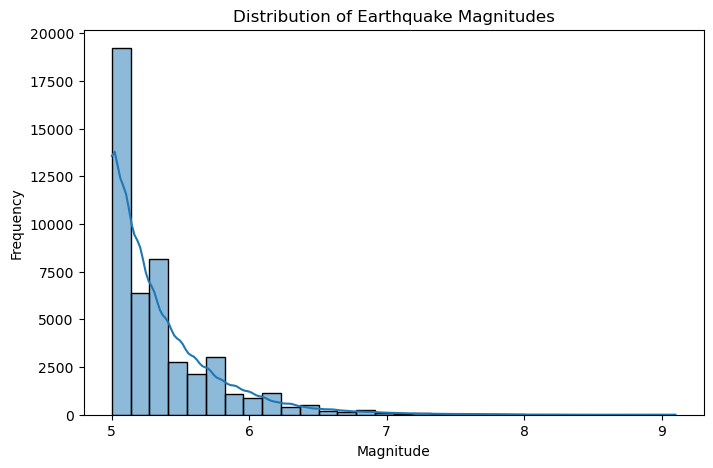

In [21]:
# Plot distribution of earthquake magnitudes
plt.figure(figsize=(8, 5))
sns.histplot(earthquake_df['mag'], bins=30, kde=True)
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Magnitudes")
plt.show()

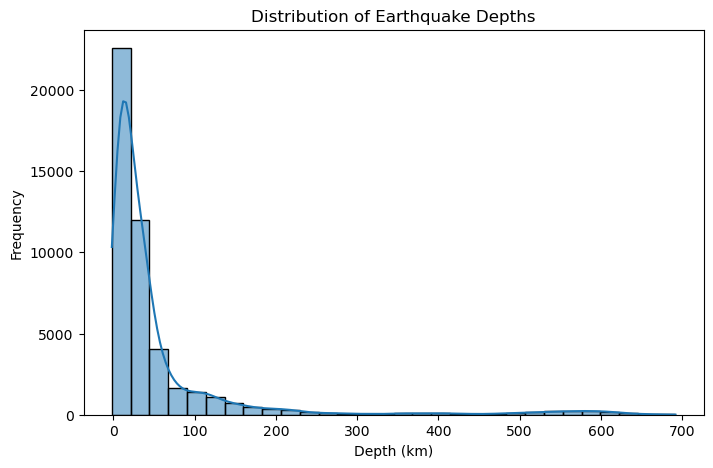

In [23]:
# Plot distribution of earthquake depths
plt.figure(figsize=(8, 5))
sns.histplot(earthquake_df['depth'], bins=30, kde=True)
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Depths")
plt.show()

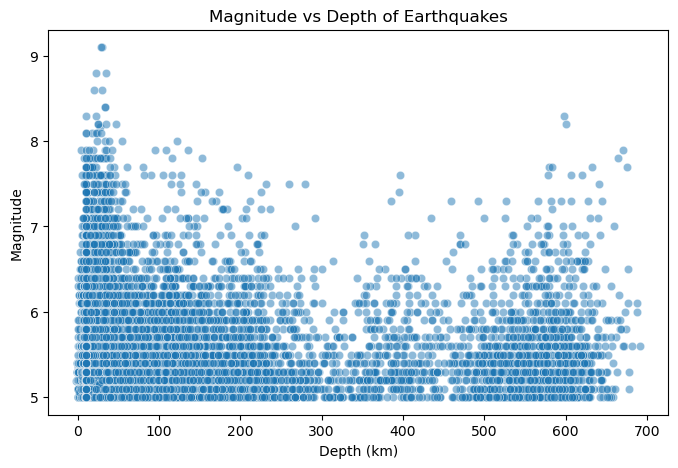

In [25]:
# Scatter plot: Magnitude vs Depth
plt.figure(figsize=(8, 5))
sns.scatterplot(x='depth', y='mag', data=earthquake_df, alpha=0.5)
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.title("Magnitude vs Depth of Earthquakes")
plt.show()

In [27]:
# Load NOAA tsunami dataset (TSV format)
tsunami_df = pd.read_csv(DATA_PATH + "tsunamis_noaa.tsv", sep="\t")

# Check dataset shape
tsunami_df.shape

(3030, 46)

In [29]:
tsunami_df.columns

Index(['Search Parameters', 'Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec',
       'Tsunami Event Validity', 'Tsunami Cause Code', 'Earthquake Magnitude',
       'Vol', 'More Info', 'Deposits', 'Country', 'Location Name', 'Latitude',
       'Longitude', 'Maximum Water Height (m)', 'Number of Runups',
       'Tsunami Magnitude (Abe)', 'Tsunami Magnitude (Iida)',
       'Tsunami Intensity', 'Deaths', 'Death Description', 'Missing',
       'Missing Description', 'Injuries', 'Injuries Description',
       'Damage ($Mil)', 'Damage Description', 'Houses Destroyed',
       'Houses Destroyed Description', 'Houses Damaged',
       'Houses Damaged Description', 'Total Deaths', 'Total Death Description',
       'Total Missing', 'Total Missing Description', 'Total Injuries',
       'Total Injuries Description', 'Total Damage ($Mil)',
       'Total Damage Description', 'Total Houses Destroyed',
       'Total Houses Destroyed Description', 'Total Houses Damaged',
       'Total Houses Damaged Description'],
 

In [31]:
# Filter valid earthquake-generated tsunami events
valid_tsunami_df = tsunami_df[
    (tsunami_df['Tsunami Event Validity'] == 1) &
    (tsunami_df['Tsunami Cause Code'] == 1)
].copy()

# Check how many valid tsunami events remain
valid_tsunami_df.shape

(321, 46)

In [33]:
#  Original datetime construction approach (NOT USED)
# This approach fails due to ancient / invalid dates in NOAA records
# valid_tsunami_df['event_time'] = pd.to_datetime(
#     valid_tsunami_df[['Year', 'Mo', 'Dy', 'Hr', 'Mn']].rename(
#         columns={'Year':'year','Mo':'month','Dy':'day','Hr':'hour','Mn':'minute'}
#     )
# )

In [35]:
# Remove ancient / invalid dates (critical fix)
valid_tsunami_df = valid_tsunami_df[
    (valid_tsunami_df['Year'] >= 1970) &
    (valid_tsunami_df['Mo'].between(1, 12)) &
    (valid_tsunami_df['Dy'].between(1, 31))
].copy()

In [37]:
valid_tsunami_df['event_time'] = pd.to_datetime(
    valid_tsunami_df[['Year', 'Mo', 'Dy', 'Hr', 'Mn']]
        .fillna(0)
        .rename(columns={
            'Year': 'year',
            'Mo': 'month',
            'Dy': 'day',
            'Hr': 'hour',
            'Mn': 'minute'
        }),
    errors='coerce'
)

valid_tsunami_df = valid_tsunami_df.dropna(subset=['event_time'])

In [39]:
earthquake_df['time'] = pd.to_datetime(earthquake_df['time'])

In [41]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [43]:
# Initialize tsunami label (0 = No, 1 = Yes)
earthquake_df['tsunami'] = 0

In [45]:
earthquake_df['time'] = pd.to_datetime(earthquake_df['time'], utc=True).dt.tz_localize(None)

In [47]:
# Ensure tsunami times are timezone-naive as well
valid_tsunami_df['event_time'] = valid_tsunami_df['event_time'].dt.tz_localize(None)

In [49]:
# Reset tsunami labels
earthquake_df['tsunami'] = 0

for i, eq in earthquake_df.iterrows():
    eq_time = eq['time']
    eq_lat = eq['latitude']
    eq_lon = eq['longitude']
    
    # Temporal window: ±6 hours
    time_window = valid_tsunami_df[
        (valid_tsunami_df['event_time'] >= eq_time - pd.Timedelta(hours=6)) &
        (valid_tsunami_df['event_time'] <= eq_time + pd.Timedelta(hours=6))
    ]
    
    # Spatial window: within 500 km
    for _, ts in time_window.iterrows():
        distance = haversine(eq_lat, eq_lon, ts['Latitude'], ts['Longitude'])
        if distance <= 500:
            earthquake_df.at[i, 'tsunami'] = 1
            break

In [50]:
earthquake_df['tsunami'].value_counts()

tsunami
0    46647
1       16
Name: count, dtype: int64

In [53]:
features = earthquake_df[['latitude', 'longitude', 'depth', 'mag']]
target = earthquake_df['tsunami']

features.shape, target.value_counts()

((46663, 4),
 tsunami
 0    46647
 1       16
 Name: count, dtype: int64)

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

y_train.value_counts(), y_test.value_counts()

(tsunami
 0    37317
 1       13
 Name: count, dtype: int64,
 tsunami
 0    9330
 1       3
 Name: count, dtype: int64)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [61]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.69      0.82      9330
           1       0.00      1.00      0.00         3

    accuracy                           0.69      9333
   macro avg       0.50      0.85      0.41      9333
weighted avg       1.00      0.69      0.82      9333

ROC-AUC: 0.8413719185423365


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [64]:
# --- Random Forest: Default threshold (0.5) ---
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9330
           1       0.00      0.00      0.00         3

    accuracy                           1.00      9333
   macro avg       0.50      0.50      0.50      9333
weighted avg       1.00      1.00      1.00      9333

ROC-AUC: 0.9997141836370131


In [65]:
# --- Random Forest: Custom threshold (0.1) for early warning ---
threshold = 0.1
y_pred_rf_thresh = (y_prob_rf >= threshold).astype(int)

print(classification_report(y_test, y_pred_rf_thresh))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9330
           1       0.30      1.00      0.46         3

    accuracy                           1.00      9333
   macro avg       0.65      1.00      0.73      9333
weighted avg       1.00      1.00      1.00      9333



In [69]:
# pip install xgboost

In [71]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [81]:
# ---- XGBoost: Default threshold (0.5) ----
y_pred_xgb_default = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost (Default Threshold = 0.5)")
print(classification_report(y_test, y_pred_xgb_default))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost (Default Threshold = 0.5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9330
           1       0.27      1.00      0.43         3

    accuracy                           1.00      9333
   macro avg       0.64      1.00      0.71      9333
weighted avg       1.00      1.00      1.00      9333

ROC-AUC: 0.9996248660235798


In [83]:
# --- XGBoost: Custom threshold (0.1) for early warning ---
threshold_xgb = 0.1
y_pred_xgb_threshold = (y_prob_xgb >= threshold_xgb).astype(int)

print("XGBoost (Custom Threshold = 0.1)")
print(classification_report(y_test, y_pred_xgb_threshold))

XGBoost (Custom Threshold = 0.1)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9330
           1       0.16      1.00      0.27         3

    accuracy                           1.00      9333
   macro avg       0.58      1.00      0.64      9333
weighted avg       1.00      1.00      1.00      9333



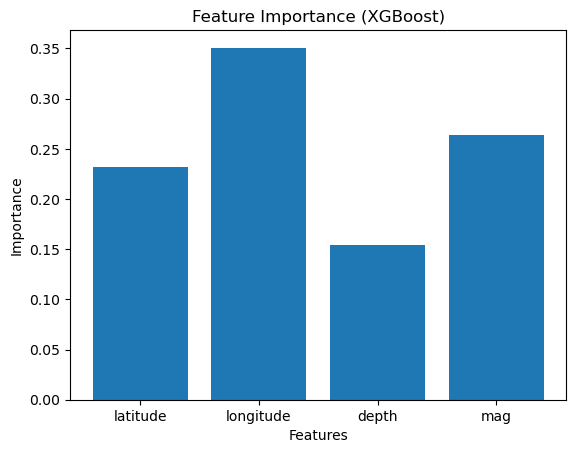

In [85]:
import matplotlib.pyplot as plt

xgb_model.feature_importances_

plt.bar(features.columns, xgb_model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [87]:
import joblib

joblib.dump(xgb_model, "xgb_tsunami_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(features.columns.tolist(), "feature_list.pkl")

['feature_list.pkl']

In [89]:
loaded_model = joblib.load("xgb_tsunami_model.pkl")
loaded_features = joblib.load("feature_list.pkl")

loaded_model, loaded_features

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ...),
 ['latitude', 'longitude', 'depth', 'mag'])